# Исследовательский анализ данных Яндекс Афиши и проверка гипотез


## Цели и задачи проекта

**Цель:** провести исследовательский анализ данных и статистический анализ, чтобы:
- выявить сезонные изменения пользовательского спроса и популярности событий,
- оценить различия в поведении пользователей мобильных и стационарных устройств,
- сформулировать и проверить статистические гипотезы по активности пользователей.

**Задачи:**
- описать доступные датасеты и подготовить их к анализу,
- провести EDA по сезонности, структуре заказов и активности пользователей,
- выделить популярные события, регионы и партнёров,
- проверить гипотезы по активности mobile vs desktop,
- сформулировать компактные выводы и рекомендации.

## Описание данных

В анализе используются три датасета:
- `final_tickets_orders_df.csv` — данные о заказах билетов.
- `final_tickets_events_df.csv` — данные о событиях.
- `final_tickets_tenge_df.csv` — курс казахстанского тенге к российскому рублю за 2024 год для конвертации выручки в единую валюту.

Период данных: с 1 июня по 31 октября 2024 года.

## Структура 

1. Загрузка данных и первичный осмотр.
2. Предобработка данных и создание новых признаков.
3. Исследовательский анализ:
   - 3.1. Сезонность и структура заказов;
   - 3.2. Осенняя активность пользователей;
   - 3.3. Популярные регионы и партнёры.
4. Статистический анализ и проверка гипотез.
5. Итоговые выводы и рекомендации.

## Шаг 1. Загрузка данных и закомство с ними

### Шаг 1.1. Загрузка датасетов

Загружаем датасеты

In [1]:
# Загружаем библиотеки 
import pandas as pd
from scipy import stats
import math
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

In [3]:
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [4]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

### Шаг 1.2. Первичный осмотр структуры

In [5]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [6]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

- В датафрейме `df_orders` 290 849 строк и 14 столбцов.
- Пропуски присутствуют только в столбце `days_since_prev` (около 22 тыс. строк), что ожидаемо: для первого заказа пользователя нет предыдущей покупки.
- В остальных столбцах пропусков нет.
- Даты (`created_dt_msk`, `created_ts_msk`) пока в формате `object`, далее их нужно привести к типу datetime.

In [7]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [8]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


- В датафрейме `df_events` 22 427 строк и 11 столбцов.
- Пропусков нет ни в одном столбце.
- Идентификаторы (`event_id`, `city_id`, `venue_id`) имеют тип `int64`, остальные столбцы — строковые (`object`).
- Датафрейм готов к объединению с таблицей заказов и последующему анализу без дополнительной обработки пропусков.

In [9]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


- В датафрейме `df_tenge` 357 строк и 4 столбца.
- Пропусков нет ни в одном столбце.
- Столбец `data` содержит даты в текстовом формате, `nominal` и `curs` — числовые столбцы, `cdx` — код валюты.
- Таблица готова для конвертации выручки из тенге в рубли.

## Шаг 2. Предобработка данных и создание признаков

### Дубликаты и типы данных

Приводим дату и время к формату datetime в `df_orders`

In [11]:
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk'])

In [12]:
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])

Снижаем размерность числовых столбцов

In [13]:
df_orders['order_id'] = df_orders['order_id'].astype('int32')

In [14]:
df_orders['event_id'] = df_orders['event_id'].astype('int32')

In [15]:
df_orders['age_limit'] = df_orders['age_limit'].astype('int32')

In [16]:
df_orders['tickets_count'] = df_orders['tickets_count'].astype('int32')

In [17]:
df_orders['revenue'] = df_orders['revenue'].astype('float32')

In [18]:
df_orders['total'] = df_orders['total'].astype('float32')

In [19]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int32         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int32         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int32         
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float32       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int32         
 12  total                  290849 non-null  floa

Оптимизация типов позволила уменьшить объём памяти, занимаемый таблицей заказов, без потери информации и корректности расчётов.

Преобразуем столбец days_since_prev к целочисленному типу

In [20]:
df_orders['days_since_prev'] = df_orders['days_since_prev'].astype('Int64')

In [21]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,Край билетов,4,10870.990234,<NA>
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,Мой билет,2,2067.510010,<NA>
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,За билетом!,4,13984.160156,75
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,Лови билет!,2,212.279999,<NA>
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,Билеты без проблем,3,10695.429688,83


Признак `days_since_prev` отражает количество дней с предыдущей покупки.Изначально столбец имел тип `float64` и содержал пропуски (`NaN`) для первых заказов пользователей, когда предыдущей покупки ещё не было.
Перевели столбец в тип `Int64`. После преобразования пропуски отображаются как
`<NA>`, что позволяет одновременно работать с целыми значениями и корректно учитывать отсутствие предыдущей покупки.

Проверка дубликатов df_orders

In [22]:
# Явные дубликаты полностью одинаковых строк
df_orders.duplicated().sum()

0

In [23]:
# Дубликаты по order_id
df_orders['order_id'].duplicated().sum()

0

In [24]:
# Возможные неявные дубликаты бронирований:
dup_cols = ['user_id', 'event_id', 'created_dt_msk', 'tickets_count', 'revenue']
df_orders.duplicated(subset=dup_cols).sum()

53321

In [25]:
# Создаём маску «строки, которые входят в группы дубликатов по этим полям»:
dups_mask = df_orders.duplicated(subset=dup_cols, keep=False)

In [26]:
# Собираем датафрейм только с дубликатами
df_dups = df_orders[dups_mask].sort_values(dup_cols)

In [27]:
df_dups.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11,6818249,000cf0659a9f40f,2024-06-20,2024-06-20 10:49:48,516728,нет,12,rub,mobile,710.950012,Лови билет!,2,8886.940430,0
16,6818104,000cf0659a9f40f,2024-06-20,2024-06-20 12:46:11,516728,нет,12,rub,mobile,710.950012,Лови билет!,2,8886.940430,0
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.910034,Лови билет!,4,17773.869141,<NA>
12,6818220,000cf0659a9f40f,2024-06-20,2024-06-20 10:56:16,516728,нет,12,rub,mobile,1421.910034,Лови билет!,4,17773.869141,0
13,6818075,000cf0659a9f40f,2024-06-20,2024-06-20 12:42:12,516728,нет,12,rub,mobile,1421.910034,Лови билет!,4,17773.869141,0
14,6818191,000cf0659a9f40f,2024-06-20,2024-06-20 10:51:10,516728,нет,12,rub,mobile,1421.910034,Лови билет!,4,17773.869141,0
15,6818046,000cf0659a9f40f,2024-06-20,2024-06-20 12:40:27,516728,нет,12,rub,mobile,1421.910034,Лови билет!,4,17773.869141,0
17,6817959,000cf0659a9f40f,2024-06-21,2024-06-21 04:33:56,516728,нет,12,rub,mobile,1066.430054,Лови билет!,3,13330.400391,1
19,6759611,000cf0659a9f40f,2024-06-21,2024-06-21 04:35:38,516728,нет,12,rub,mobile,1066.430054,Лови билет!,3,13330.400391,0
20,6818162,000cf0659a9f40f,2024-06-21,2024-06-21 04:18:44,516728,нет,12,rub,mobile,1066.430054,Лови билет!,3,13330.400391,0


In [28]:
df_orders_clean = df_orders.drop_duplicates(subset=dup_cols, keep='first')

print('До удаления:', df_orders.shape[0])
print('После удаления:', df_orders_clean.shape[0])

До удаления: 290849
После удаления: 237528


- В исходной таблице заказов 290 849 строк.
- Явных дубликатов строк и дубликатов по `order_id` не обнаружено.
- Для поиска неявных дубликатов бронирований рассмотрели комбинацию полей:
  `user_id`, `event_id`, `created_dt_msk`, `tickets_count`, `revenue`.
- По этой комбинации нашли 53 321 повторяющуюся запись.

Примеры таких групп показывают, что строки отличаются только техническим
идентификатором (`order_id`) и временем оформления (`created_ts_msk`), при
этом пользователь, событие, дата заказа, количество билетов, выручка и сумма
заказа совпадают. 
Это позволяет интерпретировать такие строки как технические дубликаты одной
и той же покупки, а не как независимые заказы. Поэтому удаляем неявные
дубликаты и оставляем по одному наблюдению на каждую уникальную комбинацию.

Размер датафрейма уменьшился с 290 849 до 237 528 строк.

Проверка дубликатов в `df_events()`

In [29]:
df_events.duplicated().sum()

0

In [30]:
df_events['event_id'].is_unique
df_events['event_id'].duplicated().sum()

0

Таблица событий не содержит дубликатов по ключу, и мы можем
использовать её для объединения с таблицей заказов без дополнительной
обработки дубликатов.

Снижаем размерность числовых столбцов

In [31]:
int_cols_events = ['event_id', 'city_id', 'venue_id']
df_events[int_cols_events] = df_events[int_cols_events].astype('int32')

In [32]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int32 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int32 
 8   venue_id                22427 non-null  int32 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int32(3), object(8)
memory usage: 1.6+ MB


### Объеденяем датафреймы

In [33]:
df = df_orders_clean.merge(df_events, on='event_id', how='left', suffixes=('', '_event'))

print('Строк в df_orders_clean:', df_orders_clean.shape[0])
print('Строк в df:', df.shape[0])

Строк в df_orders_clean: 237528
Строк в df: 237528


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 237528 entries, 0 to 237527
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                237528 non-null  int32         
 1   user_id                 237528 non-null  object        
 2   created_dt_msk          237528 non-null  datetime64[ns]
 3   created_ts_msk          237528 non-null  datetime64[ns]
 4   event_id                237528 non-null  int32         
 5   cinema_circuit          237528 non-null  object        
 6   age_limit               237528 non-null  int32         
 7   currency_code           237528 non-null  object        
 8   device_type_canonical   237528 non-null  object        
 9   revenue                 237528 non-null  float32       
 10  service_name            237528 non-null  object        
 11  tickets_count           237528 non-null  int32         
 12  total                   237528

In [35]:
df[['event_name', 'event_type_main', 'region_name']].isna().sum()

event_name         194
event_type_main    194
region_name        194
dtype: int64

In [36]:
df[['event_name', 'event_type_main', 'region_name']].isna().mean()

event_name         0.000817
event_type_main    0.000817
region_name        0.000817
dtype: float64

В полях, описывающих событие (`event_name`, `event_type_description`,
  `event_type_main`, `organizers`, `region_name`, `city_name`, `city_id`,
  `venue_id`, `venue_name`, `venue_address`), зафиксировано по 194 пропуска,
  что составляет менее 0,1 % от числа заказов.

Такие записи интерпретируем как заказы, для которых не удалось сопоставить информацию о событии. Долю подобных записей считаем незначительной и не исключаем их из анализа, но учитываем эту особенность при интерпретации результатов.

### Шаг 2.2. Категориальные признаки

In [37]:
cat_cols = [
    'device_type_canonical',
    'currency_code',
    'cinema_circuit',
    'service_name',
    'age_limit',
    'event_type_main',
    'region_name'
]

for col in cat_cols:
    print('\n', '=' * 30)
    print(col)
    print(df[col].value_counts(dropna=False).head(15))


device_type_canonical
mobile     192662
desktop     44866
Name: device_type_canonical, dtype: int64

currency_code
rub    233758
kzt      3770
Name: currency_code, dtype: int64

cinema_circuit
нет           236325
Другое          1084
КиноСити         108
Москино            7
Киномакс           3
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

service_name
Билеты без проблем        53260
Лови билет!               33711
Билеты в руки             29236
Мой билет                 28340
Облачко                   23240
Лучшие билеты             14576
Весь в билетах            14369
Прачечная                  7884
Край билетов               5125
Тебе билет!                4389
Яблоко                     4078
Дом культуры               3603
За билетом!                2454
Городской дом культуры     2387
Show_ticket                1941
Name: service_name, dtype: int64

age_limit
16    64866
12    51875
0     46168
6     43855
18    30764
Name: age_limit, dtype: int64

event_type_main


In [38]:
cols_strip_lower = ['currency_code', 'device_type_canonical']
for col in cols_strip_lower:
    df[col] = df[col].str.strip().str.lower()

df['cinema_circuit'] = df['cinema_circuit'].str.strip()
df['service_name'] = df['service_name'].str.strip()

Анализ распределения значений в основных категориальных признаках объединённой таблицы `df`:

- `device_type_canonical` содержит две категории — `mobile` (192662 заказов)
  и `desktop` (44866 заказов), что соответствует описанию данных.
- `currency_code` включает два кода валюты: `rub` (большинство заказов)
  и `kzt`; других валют не обнаружено.
- `cinema_circuit` в большинстве случаев принимает значение «нет», что
  соответствует отсутствию привязки к сети кинотеатров, и несколько
  категорий с названиями сетей; значение «нет» рассматриваем как
  отдельную категорию, а не как пропуск.
- `service_name` отражает список билетных операторов; наиболее крупные
  партнёры обеспечивают существенную долю заказов.
- `age_limit` принимает стандартные значения возрастных ограничений
  (0, 6, 12, 16, 18), что соответствует правилам маркировки мероприятий.
- `event_type_main` включает основные типы мероприятий (концерты, театр,
  спорт, стендап, выставки, ёлки) и небольшое число пропусков (194 записи),
  связанных с отсутствием информации о событии после объединения.
- `region_name` содержит перечень регионов без явных аномальных значений.

Явных ошибок или категорий, обозначающих скрытые пропуски, не обнаружено.
При необходимости строковые значения в кодах и типах были нормализованы.

### Шаг 2.3. Количественные признаки и выбросы


- анализируем распределение количественных показателей (`revenue`, `tickets_count`, `total`),
- рассматриваем статистики (describe), гистограммы и диаграммы размаха,
- выявляем и, при необходимости, ограничиваем выбросы (например, по 99‑му процентилю),
- учитываем, что выручка изначально представлена в разных валютах (рубли и тенге).

In [39]:
# Разделяем данные по валюте
df_rub = df[df['currency_code'] == 'rub'].copy()
df_kzt = df[df['currency_code'] == 'kzt'].copy()

print('Строк в rub:', df_rub.shape[0])
print('Строк в kzt:', df_kzt.shape[0])

Строк в rub: 233758
Строк в kzt: 3770


In [40]:
# Базовые статистики по revenue и tickets_count (RUB)
print('\n=== RUB: revenue ===')
print(df_rub['revenue'].describe())

print('\n=== RUB: tickets_count ===')
print(df_rub['tickets_count'].describe())


=== RUB: revenue ===
count    233758.000000
mean        561.866882
std         893.078552
min         -90.760002
25%         125.102499
50%         369.070007
75%         808.107483
max       81174.539062
Name: revenue, dtype: float64

=== RUB: tickets_count ===
count    233758.000000
mean          2.754960
std           1.173979
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


- Выручка `revenue` имеет медиану около 370 рублей и 75-й процентиль
  около 800 рублей, при этом максимальное значение достигает ~81 тыс. рублей,
  что указывает на наличие редких заказов с очень высокой суммой. Минимальное значение выручки отрицательное, что
  может отражать возвраты или ошибки в данных.
- Количество билетов в заказе `tickets_count` варьируется от 1 до 57,
  медиана составляет 3 билета, 75-й процентиль — 4 билета. Основная масса
  заказов приходится на диапазон 2–4 билета.

Дальнейший анализ выбросов по выручке выполняем с учётом 99-го
процентиля, чтобы ограничить влияние единичных экстремальных заказов.

In [41]:
# Базовые статистики по revenue и tickets_count (KZT)
print('\n=== KZT: revenue ===')
print(df_kzt['revenue'].describe())

print('\n=== KZT: tickets_count ===')
print(df_kzt['tickets_count'].describe())


=== KZT: revenue ===
count     3770.000000
mean      4303.109375
std       4556.662109
min          0.000000
25%        416.559998
50%       3698.830078
75%       6892.129883
max      26425.859375
Name: revenue, dtype: float64

=== KZT: tickets_count ===
count    3770.000000
mean        2.762069
std         1.140626
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64


- Выручка `revenue` имеет медиану около 3,7 тыс. тенге и 75-й процентиль
  около 6,9 тыс. тенге, при максимальном значении около 26,4 тыс. тенге.
  Распределение также характеризуется правым хвостом и наличием заказов
  с нулевой выручкой.
- Количество билетов `tickets_count` варьируется от 1 до 6, медиана
  составляет 3 билета, 75-й процентиль — 4 билета.

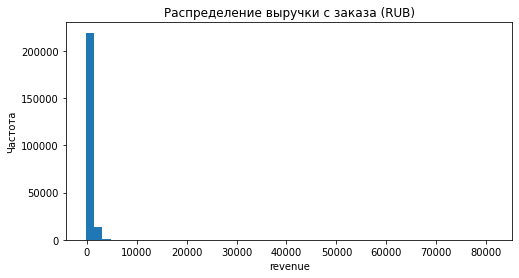

In [42]:
# гистограмма по revenue (RUB)
plt.figure(figsize=(8, 4))
plt.hist(df_rub['revenue'], bins=50)
plt.title('Распределение выручки с заказа (RUB)')
plt.xlabel('revenue')
plt.ylabel('Частота')
plt.show()

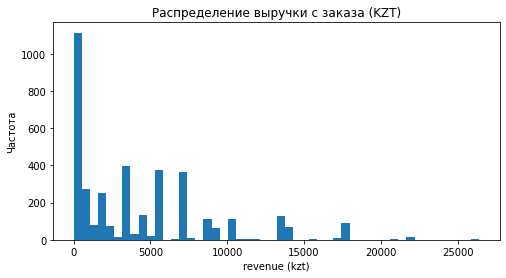

In [43]:
# гистограмма по revenue (KZT)
plt.figure(figsize=(8, 4))
plt.hist(df_kzt['revenue'], bins=50)
plt.title('Распределение выручки с заказа (KZT)')
plt.xlabel('revenue (kzt)')
plt.ylabel('Частота')
plt.show()

In [44]:
# Считаем 99‑й перцентиль
p99_rub = df_rub['revenue'].quantile(0.99)
p99_kzt = df_kzt['revenue'].quantile(0.99)

print('99-й процентиль revenue (rub):', p99_rub)
print('99-й процентиль revenue (kzt):', p99_kzt)

99-й процентиль revenue (rub): 2563.320068359375
99-й процентиль revenue (kzt): 17617.240234375


In [45]:
df_rub_trim = df_rub[df_rub['revenue'] <= p99_rub].copy()
df_kzt_trim = df_kzt[df_kzt['revenue'] <= p99_kzt].copy()

В распределении `revenue` есть отрицательные значения, которые
интерпретируем как возвраты или специальные операции. Мы сохраняем
их в данных, но при анализе выбросов ограничиваем выручку сверху
99-м процентилем, чтобы уменьшить влияние единичных крайне крупных
заказов.

In [46]:
print('RUB: было', df_rub.shape[0], 'стало', df_rub_trim.shape[0])
print('KZT: было', df_kzt.shape[0], 'стало', df_kzt_trim.shape[0])

RUB: было 233758 стало 231424
KZT: было 3770 стало 3750


In [47]:
print('=== RUB (trim): revenue ===')
print(df_rub_trim['revenue'].describe())

print('\n=== KZT (trim): revenue ===')
print(df_kzt_trim['revenue'].describe())

=== RUB (trim): revenue ===
count    231424.000000
mean        523.512878
std         501.152435
min         -90.760002
25%         123.050003
50%         361.820007
75%         793.849976
max        2563.320068
Name: revenue, dtype: float64

=== KZT (trim): revenue ===
count     3750.000000
mean      4204.988770
std       4363.367188
min          0.000000
25%        414.429993
50%       3546.139893
75%       6892.129883
max      17617.240234
Name: revenue, dtype: float64


Обрезка по 99-му процентилю позволила уменьшить влияние
редких экстремальных заказов на средние показатели, сохранив при этом
отрицательные и нулевые значения выручки, которые могут отражать
возвраты или специальные операции.

### Шаг 2.5. Конвертация валюты и новые признаки

Подготовка df_tenge и order_date

In [48]:
df_tenge['data'] = pd.to_datetime(df_tenge['data'])
df_tenge['rate_date'] = df_tenge['data'].dt.date

In [49]:
# Проверим номинал и код валюты (для информации)
print(df_tenge['nominal'].value_counts())
print(df_tenge['cdx'].value_counts())

100    357
Name: nominal, dtype: int64
kzt    357
Name: cdx, dtype: int64


In [50]:
# В df добавим дату заказа без времени
df['order_date'] = df['created_dt_msk'].dt.date

Расчёт revenue_rub

In [51]:
# Разделяем заказы по валюте
df_rub_full = df[df['currency_code'] == 'rub'].copy()
df_kzt_full = df[df['currency_code'] == 'kzt'].copy()

In [52]:
# Для RUB: revenue уже в рублях
df_rub_full['revenue_rub'] = df_rub_full['revenue']

# Для KZT: присоединяем курс по дате
df_kzt_full = df_kzt_full.merge(df_tenge[['rate_date', 'nominal', 'curs']],left_on='order_date',right_on='rate_date',
    how='left')

# Проверка пропусков курса
print('Пропуски курса для KZT:', df_kzt_full['curs'].isna().sum())

Пропуски курса для KZT: 0


In [53]:
# Конвертация: revenue (в тенге) -> рубли
df_kzt_full['revenue_rub'] = df_kzt_full['revenue'] * (df_kzt_full['curs'] / df_kzt_full['nominal'])

In [54]:
# Объединяем обратно
df_with_rev = pd.concat([df_rub_full, df_kzt_full], ignore_index=True)

print('Строк было в df:', df.shape[0])
print('Строк стало в df_with_rev:', df_with_rev.shape[0])

Строк было в df: 237528
Строк стало в df_with_rev: 237528


In [55]:
# Обновляем основной df
df = df_with_rev

Выручка с продажи одного билета one_ticket_revenue_rub

In [56]:
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

month и season

In [57]:
# Месяц оформления заказа
df['month'] = df['created_dt_msk'].dt.month

# Функция для сезона
def get_season(month):
    if month in (12, 1, 2):
        return 'зима'
    elif month in (3, 4, 5):
        return 'весна'
    elif month in (6, 7, 8):
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)

In [58]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_name,venue_address,order_date,revenue_rub,rate_date,nominal,curs,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,1521.939941,NaN,NaN,NaN,380.484985,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,...,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,289.450012,NaN,NaN,NaN,144.725006,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,...,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,1258.569946,NaN,NaN,NaN,314.642487,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,...,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,8.490000,NaN,NaN,NaN,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,...,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,1390.410034,NaN,NaN,NaN,463.470011,10,осень


На основе исходных данных сформировали несколько дополнительных
признаков:

- `revenue_rub` — выручка с заказа в рублях. 
- `one_ticket_revenue_rub` — выручка с одного билета.
- `month` — номер месяца оформления заказа.
- `season` — сезон оформления заказа.

Эти признаки будут использоваться далее при анализе сезонности, структуры заказов и средней выручки в разных разрезах.

In [59]:
# 99-й перцентиль для выручки в рублях
p99_rev_rub = df['revenue_rub'].quantile(0.99)
print('99-й процентиль revenue_rub:', p99_rev_rub)

# Обрезка по этому порогу
df_trim_rev = df[df['revenue_rub'] <= p99_rev_rub].copy()

print('Было строк:', df.shape[0])
print('Стало строк после trim:', df_trim_rev.shape[0])

99-й процентиль revenue_rub: 2594.43994140625
Было строк: 237528
Стало строк после trim: 235184


## Шаг 3. Исследовательский анализ данных (EDA)

### Шаг 3.1. Сезонность и структура заказов

In [60]:
# Количество заказов по месяцам 
orders_by_month = df.groupby('month', observed=True).agg(orders_count=('order_id', 'nunique')).reset_index().sort_values('month')

orders_by_month

,month,orders_count
0,6,29522
1,7,34448
2,8,37794
3,9,56694
4,10,79070


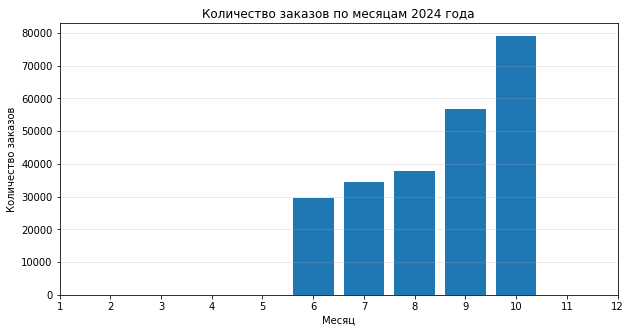

In [61]:
# Строим график
plt.figure(figsize=(10, 5))
plt.bar(orders_by_month['month'], orders_by_month['orders_count'])
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.title('Количество заказов по месяцам 2024 года')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.show()

На графике видно, что в период с июня по октябрь 2024 года количество заказов монотонно увеличивается. Особенно заметен рост в сентябре и октябре по сравнению с летними месяцами, что подтверждает сезонный эффект: осенью пользователи оформляют больше заказов.

In [62]:
#Фильтр весна-лето
df_seasons = df[df['season'].isin(['лето', 'осень'])].copy()

Доли по типу мероприятия

In [63]:
event_shares = df_seasons.groupby(['season', 'event_type_main'], observed=True).agg(orders_count=('order_id', 'nunique')).reset_index()


# считаем долю внутри сезона
event_shares['season_total'] = event_shares.groupby('season')['orders_count'].transform('sum')
event_shares['orders_share'] = event_shares['orders_count'] / event_shares['season_total']

event_shares.head(15)

,season,event_type_main,orders_count,season_total,orders_share
0,лето,выставки,2144,101590,0.021104
1,лето,другое,27308,101590,0.268806
2,лето,концерты,44026,101590,0.433369
3,лето,спорт,2265,101590,0.022296
4,лето,стендап,5579,101590,0.054917
5,лето,театр,20027,101590,0.197136
6,лето,ёлки,241,101590,0.002372
7,осень,выставки,2117,135744,0.015596
8,осень,другое,27924,135744,0.205711
9,осень,концерты,52853,135744,0.389358


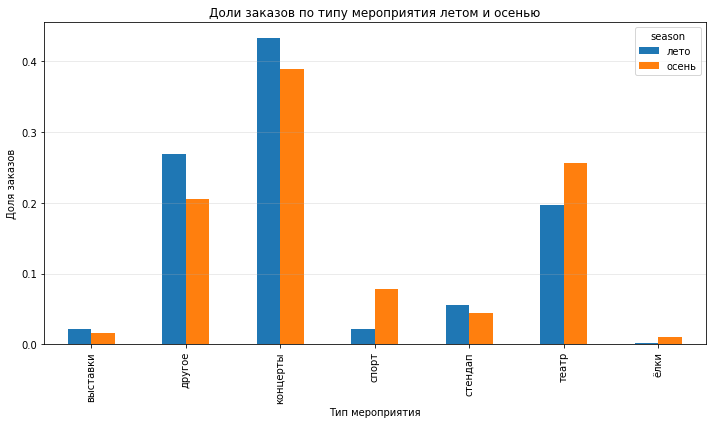

In [64]:
pivot_event = event_shares.pivot(index='event_type_main', columns='season', values='orders_share').fillna(0)


pivot_event.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Доля заказов')
plt.xlabel('Тип мероприятия')
plt.title('Доли заказов по типу мероприятия летом и осенью')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

На графике показано распределение долей заказов по типам мероприятий для летнего и осеннего сезонов. В обоих периодах основная часть заказов приходится на концерты, при этом осенью их доля немного снижается.
Доля театральных мероприятий, наоборот, осенью возрастает по сравнению с летом. Для остальных типов мероприятий (спорт, стендап, выставки, «другое» и новогодние ёлки) доли остаются на низком уровне и меняются незначительно.

Доли по типу устройства

In [65]:
# Тип устройства
device_shares = df_seasons.groupby(['season', 'device_type_canonical'], observed=True).agg(orders_count=('order_id', 'nunique')).reset_index()

device_shares['season_total'] = device_shares.groupby('season')['orders_count'].transform('sum')
device_shares['orders_share'] = device_shares['orders_count'] / device_shares['season_total']

device_shares

,season,device_type_canonical,orders_count,season_total,orders_share
0,лето,desktop,19260,101764,0.189261
1,лето,mobile,82504,101764,0.810739
2,осень,desktop,25606,135764,0.188607
3,осень,mobile,110158,135764,0.811393


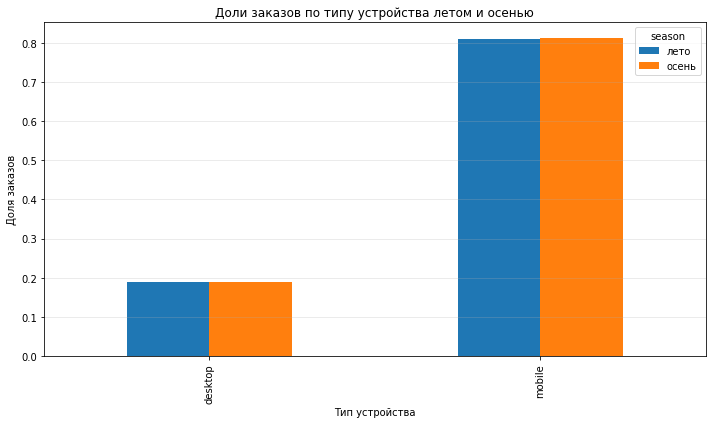

In [66]:
pivot_device = device_shares.pivot(index='device_type_canonical', columns='season', values='orders_share').fillna(0)


pivot_device.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Доля заказов')
plt.xlabel('Тип устройства')
plt.title('Доли заказов по типу устройства летом и осенью')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

В обоих сезонных периодах основная часть заказов оформляется с мобильных устройств (около 80%), доля десктопов остаётся на уровне 20%.

In [67]:
# Возрастной рейтинг
age_shares = df_seasons.groupby(['season', 'age_limit'], observed=True).agg(orders_count=('order_id', 'nunique')).reset_index()

age_shares['season_total'] = age_shares.groupby('season')['orders_count'].transform('sum')
age_shares['orders_share'] = age_shares['orders_count'] / age_shares['season_total']

age_shares

,season,age_limit,orders_count,season_total,orders_share
0,лето,0,18068,101764,0.177548
1,лето,6,18491,101764,0.181705
2,лето,12,20882,101764,0.205200
3,лето,16,28888,101764,0.283872
4,лето,18,15435,101764,0.151674
5,осень,0,28100,135764,0.206977
6,осень,6,25364,135764,0.186824
7,осень,12,30993,135764,0.228286
8,осень,16,35978,135764,0.265004
9,осень,18,15329,135764,0.112909


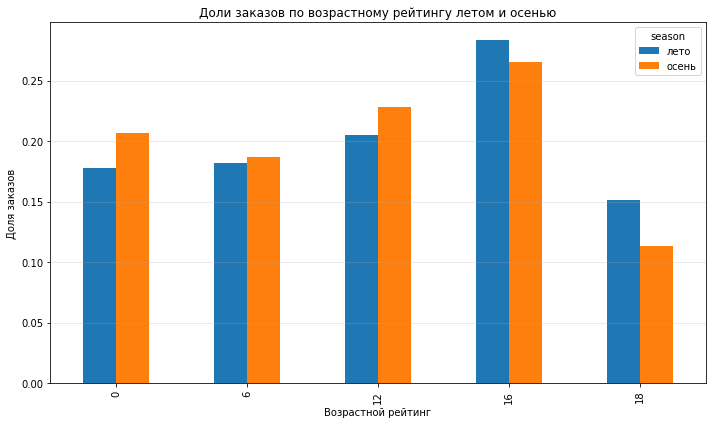

In [68]:
pivot_age = age_shares.pivot(index='age_limit', columns='season', values='orders_share').fillna(0)


pivot_age.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Доля заказов')
plt.xlabel('Возрастной рейтинг')
plt.title('Доли заказов по возрастному рейтингу летом и осенью')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

На графике показано распределение долей заказов по возрастным рейтингам в летний и осенний периоды. Наибольшая доля заказов в оба сезона приходится на мероприятия с рейтингом 16+, однако осенью она немного снижается. При этом доли категорий 0+ и 12+ осенью увеличиваются, тогда как категория 18+ теряет часть заказов по сравнению с летом. В целом можно предположить, что с наступлением осени интерес пользователей несколько смещается в сторону более массовых и семейных мероприятий.

Средняя выручка за билет летом и осенью по типу мероприятия

In [69]:
# Берём только обрезанную по p99 выборку и сезоны лето/осень
sub_trim = df_trim_rev[df_trim_rev['season'].isin(['лето', 'осень'])].copy()

avg_one_ticket = sub_trim.groupby(['season', 'event_type_main'], observed=True).agg(orders_count=('order_id', 'nunique'),
        mean_one_ticket_rev=('one_ticket_revenue_rub', 'mean')).reset_index()

avg_one_ticket

,season,event_type_main,orders_count,mean_one_ticket_rev
0,лето,выставки,2144,86.667637
1,лето,другое,27234,78.684882
2,лето,концерты,43158,295.919552
3,лето,спорт,2258,55.687699
4,лето,стендап,5532,216.612884
5,лето,театр,19812,214.000741
6,лето,ёлки,238,274.258487
7,осень,выставки,2116,89.764035
8,осень,другое,27873,77.702686
9,осень,концерты,52161,272.479913


In [70]:
# Поворот таблицы
pivot_avg = avg_one_ticket.pivot(index='event_type_main', columns='season', values='mean_one_ticket_rev').reset_index()


pivot_avg.columns.name = None
print(pivot_avg.columns)
pivot_avg

Index(['event_type_main', 'лето', 'осень'], dtype='object')


,event_type_main,лето,осень
0,выставки,86.667637,89.764035
1,другое,78.684882,77.702686
2,концерты,295.919552,272.479913
3,спорт,55.687699,56.061255
4,стендап,216.612884,231.349005
5,театр,214.000741,176.200725
6,ёлки,274.258487,232.553895


Относительное изменение осенних значений по сравнению с летними

In [71]:
pivot_avg['rel_change_autumn_vs_summer'] = (pivot_avg['осень'] - pivot_avg['лето']) / pivot_avg['лето']

pivot_avg

,event_type_main,лето,осень,rel_change_autumn_vs_summer
0,выставки,86.667637,89.764035,0.035727
1,другое,78.684882,77.702686,-0.012483
2,концерты,295.919552,272.479913,-0.079209
3,спорт,55.687699,56.061255,0.006708
4,стендап,216.612884,231.349005,0.068030
5,театр,214.000741,176.200725,-0.176635
6,ёлки,274.258487,232.553895,-0.152063


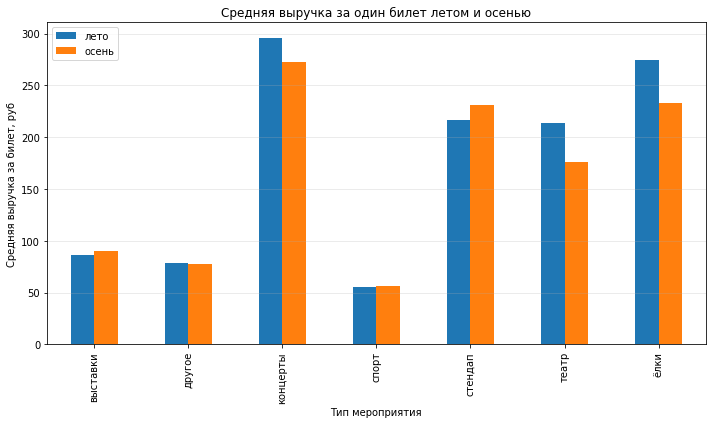

In [72]:
pivot_means = pivot_avg.set_index('event_type_main')[['лето', 'осень']]

pivot_means.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Средняя выручка за билет, руб')
plt.xlabel('Тип мероприятия')
plt.title('Средняя выручка за один билет летом и осенью')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Для оценки изменения средней стоимости билета использовали признак `one_ticket_revenue_rub` и выборку, обрезанную по 99-му процентилю `revenue_rub`. Для каждого типа мероприятия рассчитали среднюю выручку за билет летом и осенью, а затем относительное изменение осенних значений по сравнению с летними.

Результаты показывают, что осенью средний чек заметно снижается для
театральных мероприятий (примерно на 18 %) и ёлок (на 15 %), а также умеренно падает для концертов (около 8 %). Для спортивных мероприятий и категории «другое» средняя стоимость билета остаётся почти неизменной, а для стендап‑шоу и выставок наблюдается небольшой рост среднего чека (порядка 4–7 %).

### Шаг 3.2. Осенняя активность пользователей

In [73]:
# берём только осень
df_autumn = df[df['season'] == 'осень'].copy()

In [74]:
# день оформления заказа
df_autumn['order_date'] = df_autumn['created_dt_msk'].dt.date

Общее число заказов и DAU

In [75]:
daily_stats = df_autumn.groupby('order_date', observed=True).agg(
        orders_count=('order_id', 'nunique'),      # общее число заказов
        dau=('user_id', 'nunique'),                # количество уникальных пользователей
        total_revenue_rub=('revenue_rub', 'sum'),  # суммарная выручка в рублях
        mean_one_ticket_rev=('one_ticket_revenue_rub', 'mean')  # средняя цена билета
    ).reset_index()


 Среднее число заказов на пользователя

In [76]:
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

In [77]:
daily_stats

,order_date,orders_count,dau,total_revenue_rub,mean_one_ticket_rev,orders_per_user
0,2024-09-01,1125,569,6.457729e+05,209.209586,1.977153
1,2024-09-02,1182,580,6.253381e+05,194.249181,2.037931
2,2024-09-03,2391,783,8.012130e+05,119.470722,3.053640
3,2024-09-04,1463,688,7.702594e+05,187.737651,2.126453
4,2024-09-05,1677,745,9.073520e+05,197.229086,2.251007
...,...,...,...,...,...,...
56,2024-10-27,2424,1039,1.298780e+06,192.576013,2.333013
57,2024-10-28,2435,988,1.231097e+06,178.243554,2.464575
58,2024-10-29,2409,1005,1.233000e+06,184.994377,2.397015
59,2024-10-30,2511,1050,1.315950e+06,187.017284,2.391429


Общее число заказов

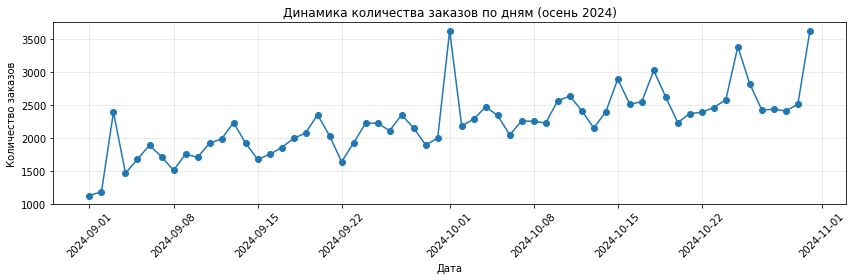

In [78]:
plt.figure(figsize=(12, 4))
plt.plot(daily_stats['order_date'], daily_stats['orders_count'], marker='o')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Динамика количества заказов по дням (осень 2024)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На графике показано изменение общего числа заказов по дням в течение осени 2024 года. В целом наблюдается восходящий тренд, от начала сентября к концу октября количество заказов постепенно растёт. Отдельно выделяются несколько пиковых дней, в том числе резкий всплеск в начале октября и максимум 31 октября, когда количество заказов
существенно превышает средний уровень. Это подтверждает усиление осенней активности пользователей и возможное влияние отдельных
маркетинговых акций или событий.

DAU (активные пользователи)

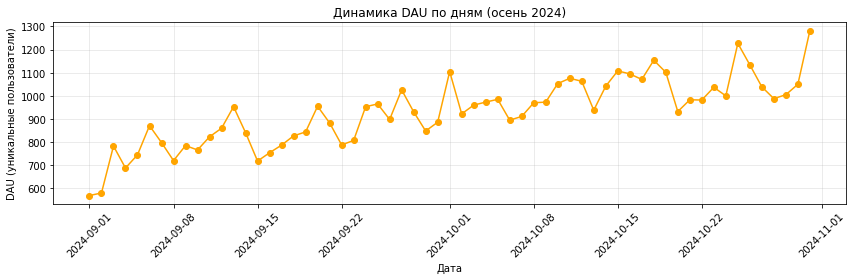

In [79]:
plt.figure(figsize=(12, 4))
plt.plot(daily_stats['order_date'], daily_stats['dau'], marker='o', color='orange')
plt.xlabel('Дата')
plt.ylabel('DAU (уникальные пользователи)')
plt.title('Динамика DAU по дням (осень 2024)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Наблюдается устойчивый рост DAU: если в начале сентября число активных пользователей находится на уровне
около 600–700 человек в день, то к концу октября оно достигает примерно 1200–1300 пользователей. Локальные пики и просадки
совпадают по времени с изменениями в количестве заказов, что указывает на то, что рост суммарного числа заказов осенью связан прежде всего с расширением ежедневной пользовательской аудитории.

Среднее число заказов на пользователя

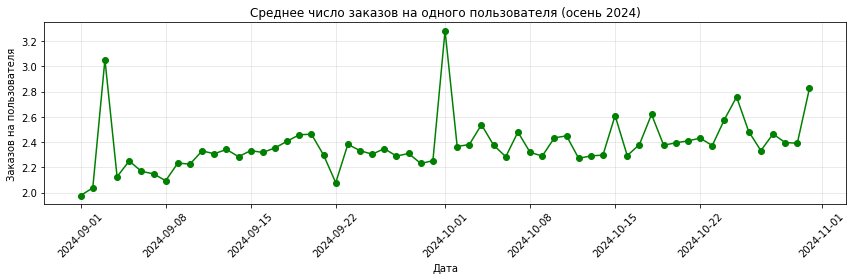

In [80]:
plt.figure(figsize=(12, 4))
plt.plot(daily_stats['order_date'], daily_stats['orders_per_user'], marker='o', color='green')
plt.xlabel('Дата')
plt.ylabel('Заказов на пользователя')
plt.title('Среднее число заказов на одного пользователя (осень 2024)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В большинство дней показатель держится на уровне чуть выше двух заказов на пользователя, что говорит о том, что активные пользователи часто оформляют более одного заказа в день. При этом в отдельные даты в начале сентября и начале октября наблюдаются всплески до трёх и более заказов на пользователя, что может быть связано с акционными предложениями или массовыми
мероприятиями, стимулирующими повторные покупки в течение дня.

Средняя стоимость одного билета

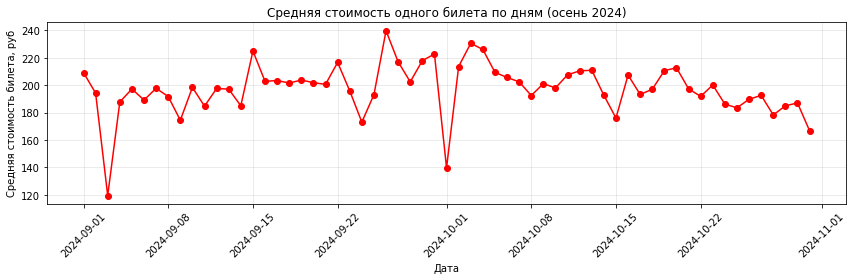

In [81]:
plt.figure(figsize=(12, 4))
plt.plot(daily_stats['order_date'], daily_stats['mean_one_ticket_rev'], marker='o', color='red')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость билета, руб')
plt.title('Средняя стоимость одного билета по дням (осень 2024)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В большинстве дней средняя цена билета находится в диапазоне примерно 180–230 рублей, что говорит об относительной стабильности стоимости. В отдельные даты наблюдаются более заметные просадки и всплески, однако они носят краткосрочный характер и могут быть связаны с разными акциями, изменением структуры мероприятий или разовым преобладанием более
дешёвых или, наоборот, более дорогих событий. В целом осенний рост выручки обусловлен скорее увеличением количества заказов и числа активных пользователей, чем систематическим ростом цены билета.

In [82]:
# День недели: 0=понедельник, 6=воскресенье
df_autumn['weekday'] = df_autumn['created_dt_msk'].dt.weekday

In [83]:
weekday_map = {
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье',
}
df_autumn['weekday_name'] = df_autumn['weekday'].map(weekday_map)


In [84]:
# Сводная по дням + дню недели
daily_stats['weekday'] = pd.to_datetime(daily_stats['order_date']).dt.weekday
daily_stats['weekday_name'] = daily_stats['weekday'].map(weekday_map)

In [85]:
# Признак «будни / выходные»
def weekday_type(w):
    return 'выходной' if w in (5, 6) else 'будний'

daily_stats['day_type'] = daily_stats['weekday'].apply(weekday_type)

In [86]:
weekly_cycle = daily_stats.groupby('day_type', observed=True).agg(mean_orders_count=('orders_count', 'mean'),
        mean_dau=('dau', 'mean'),
        mean_orders_per_user=('orders_per_user', 'mean'),
        mean_one_ticket_rev=('mean_one_ticket_rev', 'mean')).reset_index()


weekly_cycle

,day_type,mean_orders_count,mean_dau,mean_orders_per_user,mean_one_ticket_rev
0,будний,2297.022727,943.704545,2.417391,194.294033
1,выходной,2040.882353,893.176471,2.268717,205.191044


Анализ осенних данных показал выраженную недельную цикличность.В будние дни среднее дневное количество заказов и число активных
пользователей (DAU) выше, чем в выходные. Пользователи делают в среднем около 2.4 заказов на человека против 2.3 заказов в выходные. Это говорит о том, что основной объём заказов приходится именно на будние
дни. При этом средняя стоимость одного билета осенью немного выше в выходные, что может быть связано с преобладанием более дорогих мероприятий в выходные дни.

### Шаг 3.3. Популярные события и партнёры

Метрики по регионам

In [87]:
regions_stats = df.groupby('region_name', observed=True).agg(
        unique_events=('event_id', 'nunique'),
        orders_count=('order_id', 'nunique'),
        total_revenue_rub=('revenue_rub', 'sum')).reset_index()


In [88]:
# Общее количество уникальных мероприятий и заказов
total_events = regions_stats['unique_events'].sum()
total_orders = regions_stats['orders_count'].sum()

regions_stats['events_share'] = regions_stats['unique_events'] / total_events
regions_stats['orders_share'] = regions_stats['orders_count'] / total_orders

regions_stats.sort_values('unique_events', ascending=False).head()

,region_name,unique_events,orders_count,total_revenue_rub,events_share,orders_share
23,Каменевский регион,5983,75617,5.173538e+07,0.266777,0.318610
60,Североярская область,3814,37794,2.167163e+07,0.170063,0.159244
77,Широковская область,1233,13807,7.741271e+06,0.054978,0.058175
57,Светополянский округ,1075,6383,2.850948e+06,0.047933,0.026895
52,Речиновская область,702,5235,2.267138e+06,0.031302,0.022058


Распределение событий по регионам показывает, что наибольшее разнообразие мероприятий и объём заказов сосредоточены в нескольких
ключевых регионах. Каменевский регион обеспечивает более четверти всех уникальных мероприятий и около трети заказов, будучи главным центром событий. Существенный вклад также вносит Североярская область, тогда как остальные регионы формируют меньшие, но заметные доли заказов и выручки.

Метрики по билетным партнёрам

In [89]:
partners_stats = df.groupby('service_name', observed=True).agg(unique_events=('event_id', 'nunique'),
        orders_count=('order_id', 'nunique'),
        total_revenue_rub=('revenue_rub', 'sum')).reset_index()


In [90]:
total_partner_events = partners_stats['unique_events'].sum()
total_partner_orders = partners_stats['orders_count'].sum()
total_partner_revenue = partners_stats['total_revenue_rub'].sum()

partners_stats['events_share'] = partners_stats['unique_events'] / total_partner_events
partners_stats['orders_share'] = partners_stats['orders_count'] / total_partner_orders
partners_stats['revenue_share'] = partners_stats['total_revenue_rub'] / total_partner_revenue

partners_stats.sort_values('total_revenue_rub', ascending=False).head()

,service_name,unique_events,orders_count,total_revenue_rub,events_share,orders_share,revenue_share
3,Билеты без проблем,4262,53260,2.301180e+07,0.174272,0.224226,0.171076
24,Мой билет,1310,28340,1.882417e+07,0.053566,0.119312,0.139944
25,Облачко,2348,23240,1.882334e+07,0.096009,0.097841,0.139938
8,Весь в билетах,867,14369,1.540623e+07,0.035451,0.060494,0.114534
21,Лови билет!,4883,33711,1.409011e+07,0.199665,0.141924,0.104750


Анализ по билетным партнёрам выявляет аналогичную концентрацию.Небольшая группа сервисов («Билеты без проблем», «Лови билет!»,
«Облачко», «Мой билет», «Весь в билетах») собирает большую часть уникальных мероприятий, заказов и суммарной выручки. При этом
«Билеты без проблем» выделяется как один из лидеров по числу заказов и выручке, а «Лови билет!» — по количеству проводимых мероприятий. Остальные партнёры обрабатывают существенно меньшие объёмы.

## Шаг 4. Статистический анализ и проверка гипотез

Подготовка данных

In [91]:
# фильтр по осени и только нужные колонки
df_autumn = df[df['season'] == 'осень'].copy()
df_autumn = df_autumn[df_autumn['created_dt_msk'].dt.year == 2024].copy()

# убедимся, что тип устройства нормализован
df_autumn['device_type_canonical'].value_counts()

mobile     110158
desktop     25606
Name: device_type_canonical, dtype: int64

Гипотеза 1: среднее количество заказов на пользователя

Подготовка выборок

In [99]:
# считаем заказы на пользователя по типу устройства
user_orders = (
    df_autumn
    .groupby(['device_type_canonical', 'user_id'], observed=True)
    .agg(orders_count=('order_id', 'nunique'))
    .reset_index()
)

mobile_orders = user_orders[user_orders['device_type_canonical'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type_canonical'] == 'desktop']['orders_count']

In [101]:
# пользователи по устройствам
mobile_users = set(
    user_orders[user_orders['device_type_canonical'] == 'mobile']['user_id']
)
desktop_users = set(
    user_orders[user_orders['device_type_canonical'] == 'desktop']['user_id']
)

only_mobile = mobile_users - desktop_users
only_desktop = desktop_users - mobile_users
both_devices = mobile_users & desktop_users

print('Пользователей только mobile:', len(only_mobile))
print('Пользователей только desktop:', len(only_desktop))
print('Пользователей с обоими типами устройств:', len(both_devices))

Пользователей только mobile: 10991
Пользователей только desktop: 1646
Пользователей с обоими типами устройств: 3237


Перед выбором статистического критерия исследуем структуру данных и выборок.

Единица наблюдения для гипотезы 1 — пользователь: каждое наблюдение соответствует одному пользователю и количеству его заказов в осенний период для конкретного типа устройства.


Тип данных: количественная неотрицательная счетная величина (число заказов), распределение правосторонне асимметрично, с тяжёлыми хвостами и выбросами (есть пользователи с сотнями и тысячами заказов).


Независимость наблюдений: отдельные пользователи могут совершать заказы с обоих устройств, поэтому выборки mobile и desktop частично пересекаются по user_id. Это означает, что формально предпосылка независимости выборок нарушается, и результаты критериев стоит интерпретировать с осторожностью.


Размер выборки: число пользователей в каждой группе достаточно велико, чтобы использовать непараметрические критерии с хорошей мощностью.


Распределение и выбросы: описательная статистика показывает сильную асимметрию и большие значения стандартного отклонения относительно среднего, что делает параметрические тесты (t‑test) чувствительными к выбросам и отклонениям от нормальности.


С учётом счетного типа метрики, асимметричного распределения, выбросов и нарушенной нормальности используем непараметрический критерий Манна–Уитни для сравнения распределений числа заказов на пользователя между мобильными и десктопными пользователями. Критерий не требует нормальности и устойчивее к выбросам, чем t‑test.


Формулировка гипотезы (односторонний тест):

​H0: распределения числа заказов на пользователя orders_count у мобильных и десктопных пользователей одинаковы; вероятность того, что число заказов у случайного мобильного пользователя больше, чем у десктопного, равна 0.5 или меньше.

​H1: распределение orders_count у мобильных пользователей сдвинуто вправо относительно десктопных (вероятность, что число заказов у случайного мобильного пользователя больше, чем у десктопного, строго больше 0.5), то есть активность мобильных пользователей не меньше и, как минимум для части аудитории, выше.


In [93]:
# описательные статистики
print('mobile:', mobile_orders.describe())
print('desktop:', desktop_orders.describe())

# тест Манна–Уитни (односторонний: mobile > desktop)
u_stat, p_value = stats.mannwhitneyu(
    mobile_orders,
    desktop_orders,
    alternative='greater'
)

print('U-stat:', u_stat, 'p-value:', p_value)

mobile: count    14228.000000
mean         7.742339
std         56.473630
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       3734.000000
Name: orders_count, dtype: float64
desktop: count    4883.000000
mean        5.243907
std        26.861032
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max      1201.000000
Name: orders_count, dtype: float64
U-stat: 36750772.0 p-value: 8.516377401164806e-11


Критерий Манна–Уитни (альтернатива mobile > desktop) дал статистически значимое отличие в пользу мобильных устройств: 
𝑝-value≈8.5⋅10−11<0.05, поэтому нулевая гипотеза отвергается. Распределение числа заказов на пользователя у mobile сдвинуто вправо относительно desktop: среднее значение выше (7.7 против 5.2 заказа), при схожей медиане (2 заказа на пользователя), а различия проявляются в хвостах (есть больше пользователей с очень высокой активностью на мобильных устройствах).

Гипотеза 2: среднее время между заказами

In [94]:
# сортируем
df_autumn_sorted = df_autumn.sort_values(['user_id', 'created_dt_msk']).copy()

# считаем разницу во времени между заказами пользователя
df_autumn_sorted['time_diff'] = (
    df_autumn_sorted
    .groupby('user_id')['created_dt_msk']
    .diff()
)

# убираем первую строку по каждому пользователю (там NaT)
intervals = df_autumn_sorted.dropna(subset=['time_diff']).copy()

# переводим разницу во времени в часы 
intervals['time_diff_hours'] = intervals['time_diff'].dt.total_seconds() / 3600

mobile_intervals = intervals[intervals['device_type_canonical'] == 'mobile']['time_diff_hours']
desktop_intervals = intervals[intervals['device_type_canonical'] == 'desktop']['time_diff_hours']

In [95]:
mobile_intervals

5         456.0
8         384.0
20        312.0
24        720.0
26        696.0
          ...  
233750     24.0
233751    144.0
233752     96.0
233753     24.0
233754      0.0
Name: time_diff_hours, Length: 96924, dtype: float64

In [97]:
desktop_intervals

30          0.0
31        336.0
32          0.0
80          0.0
81          0.0
          ...  
233625      0.0
233626      0.0
233645    576.0
233747     48.0
233755     72.0
Name: time_diff_hours, Length: 22966, dtype: float64

Для гипотезы 2 единицей наблюдения является интервал между соседними заказами одного пользователя, измеренный в часах (time_diff_hours).


Распределение интервалов также сильно асимметрично: есть нулевые и малые значений (заказы подряд), но есть длинные хвосты из редких заказов, что нарушает предпосылки нормальности для t‑test.

С учётом этого для сравнения используем критерий Манна–Уитни как непараметрический тест на сдвиг распределений интервалов между заказами между группами mobile и desktop.


Формулировка гипотезы (односторонний тест):

​H0: распределения интервалов между заказами time_diff_hours у пользователей mobile и desktop одинаковы; вероятность, что интервал у mobile больше, чем у desktop, не превышает 0.5.

​H1: распределение time_diff_hours у мобильных пользователей сдвинуто вправо относительно десктопных (вероятность, что интервал между заказами у mobile больше, чем у desktop, больше 0.5), то есть среди мобильной аудитории больше пользователей с длительными паузами между покупками.

In [96]:
print('mobile intervals:', mobile_intervals.describe())
print('desktop intervals:', desktop_intervals.describe())

u_stat2, p_value2 = stats.mannwhitneyu(
    mobile_intervals,
    desktop_intervals,
    alternative='greater'  # mobile > desktop
)

print('U-stat 2:', u_stat2, 'p-value 2:', p_value2)

mobile intervals: count    96924.000000
mean        46.421444
std        129.141483
min          0.000000
25%          0.000000
50%          0.000000
75%         24.000000
max       1416.000000
Name: time_diff_hours, dtype: float64
desktop intervals: count    22966.000000
mean        41.438300
std        123.930235
min          0.000000
25%          0.000000
50%          0.000000
75%         24.000000
max       1416.000000
Name: time_diff_hours, dtype: float64
U-stat 2: 1154266342.5 p-value 2: 1.4146636268333993e-25


Полученное 
p-value≈1.4⋅10−25 значительно ниже уровня значимости 0.05, поэтому отвергаем H0 в пользу H1. Распределение интервалов между заказами у мобильных пользователей статистически значимо сдвинуто вправо: среднее значение выше (46 часов против 41 часа), при одинаковой медиане (0 часов) и совпадающих квартилях, а различия проявляются преимущественно в хвостах — у части мобильной аудитории наблюдаются более длительные паузы между покупками.

## Шаг 5. Итоговые выводы и рекомендации

### Основные результаты анализа
Популярность мероприятий и сезонность


Основной объём заказов приходится на концерты и театральные постановки. На их долю приходится наибольшее количество заказов и значительная часть выручки.

В течение года и особенно осенью наблюдается сезонный рост: от июня к ноябрю число заказов заметно увеличивается, при этом осенью меняется структура спроса — растёт доля театральных мероприятий, тогда как доля концертов может немного снижаться.

В разрезе устройств структура заказов стабильно мобильная: подавляющее большинство заказов оформляется с мобильных устройств, доля десктопа меньше и почти не меняется между летом и осенью.

По возрастным рейтингам спрос распределён относительно равномерно между 0+, 12+, 16+, однако осенью немного смещается в сторону более массовых категорий (0+ и 12+).

Средний чек и выручка за билет

После обрезки верхних 1% заказов по revenue_rub распределение выручки и выручки за один билет стало более стабильным, без сильного влияния экстремальных заказов.

Осенью средняя стоимость одного билета в целом остаётся в относительно узком диапазоне (около 180–230 руб в зависимости от дня), без явного тренда на резкий рост или падение. Рост выручки осенью связан прежде всего с увеличением числа заказов и активных пользователей.

В разрезе типов мероприятий осенью средний чек по концертам и особенно по театру и ёлкам снижается по сравнению с летом, тогда как для стендапа и выставок наблюдается небольшой рост средней цены билета. Это может отражать расширение ассортимента за счёт более доступных массовых мероприятий в пиковый сезон.

Осенняя пользовательская активность и недельная цикличность

Осенью 2024 года по дням фиксируется устойчивый рост количества заказов и DAU: к концу октября и числу заказов, и размеру активной ежедневной аудитории удаётся выйти на заметно более высокий уровень, чем в начале сентября.

Среднее число заказов на одного активного пользователя большую часть осени держится выше двух, а в отдельные дни превышает три, что указывает на выраженную склонность части аудитории делать несколько заказов в рамках одного дня.

Недельная цикличность выражена: в будние дни среднее дневное количество заказов и DAU выше, чем в выходные, а среднее число заказов на пользователя также немного больше. При этом средняя стоимость билета слегка выше в выходные, что говорит о смещении ассортимента в сторону более дорогих мероприятий в конце недели.

Регионы и партнёры

По регионам спрос и предложение мероприятий сконцентрированы в нескольких ключевых центрах: один-два региона обеспечивают наибольшее разнообразие событий (по числу уникальных мероприятий) и крупную долю заказов и выручки, тогда как остальные регионы формируют меньшие, но значимые доли.

Среди билетных партнёров также наблюдается концентрация: небольшое число крупных сервисов обрабатывает большую часть мероприятий, заказов и выручки. Отдельные партнёры лидируют по разнообразию мероприятий, другие — по числу заказов и выручке.

### Результаты проверки гипотез

Гипотеза 1: число заказов на пользователя

Рассматривалось число заказов на пользователя в осенний период отдельно для мобильных и десктопных устройств. Из‑за выраженной асимметрии распределения и наличия выбросов в числе заказов (есть пользователи с очень большим количеством покупок) был выбран непараметрический критерий Манна–Уитни, который сравнивает распределения метрики между двумя группами без предположения нормальности.

Нулевая гипотеза формулировалась как отсутствие сдвига распределений числа заказов на пользователя между группами mobile и desktop; альтернативная гипотеза (односторонняя) — что распределение orders_count у мобильных пользователей сдвинуто вправо, то есть вероятность получить большее число заказов у mobile выше, чем у desktop.

По результатам теста нулевая гипотеза отвергнута. Распределение числа заказов на пользователя у мобильных пользователей статистически значимо сдвинуто вправо по сравнению с десктопными: при одинаковой медиане (типичный пользователь обеих групп делает около двух заказов) у мобильных сильнее выражен «хвост» сверхактивных клиентов, и среднее число заказов на пользователя выше (7.7 против 5.2). Это указывает на наличие сегмента мобильной аудитории с более высокой частотой покупок.

Гипотеза 2: время между заказами

Интервалы между заказами рассчитывались как разница по времени между соседними заказами одного пользователя в осенний период (в часах), отдельно для мобильных и десктопных устройств. Распределения интервалов также сильно асимметричны: много нулевых и малых значений и длинные хвосты из редких покупок, поэтому для проверки гипотезы также применялся критерий Манна–Уитни.

Нулевая гипотеза: распределения интервалов между заказами у пользователей mobile и desktop не отличаются; альтернативная (односторонняя): распределение интервалов time_diff_hours у mobile сдвинуто вправо, то есть промежутки между заказами у части мобильных пользователей больше, чем у десктопных.

Нулевая гипотеза также отвергнута. Распределение интервалов между заказами у мобильных пользователей статистически значимо сдвинуто вправо: средний интервал выше (46 часов против 41 часа), при том что медианы совпадают (0 часов), а квартильные значения одинаковы. Это говорит о большей неоднородности мобильной аудитории: в ней одновременно присутствует сегмент очень активных пользователей и сегмент, делающий заказы с более длительными паузами.

Ограничения интерпретации

Важно отметить, что один пользователь может совершать несколько заказов в период наблюдения, а также использовать оба типа устройств (mobile и desktop), поэтому выборки по устройствам частично пересекаются по user_id, и предпосылка полной независимости наблюдений и выборок выполняется лишь приближённо. Это может немного искажать оценки статистической значимости, поэтому полученные результаты следует рассматривать как указание на наличие эффектов в поведении мобильных и десктопных пользователей, а не как строгое доказательство причинных различий между группами.

### Рекомендации

Сфокусироваться на мобильной аудитории.

Мобильные пользователи формируют основную часть заказов и показывают более высокую активность, поэтому имеет смысл приоритизировать развитие мобильного приложения, удобство сценариев покупки и персональные предложения именно для этой группы.

Использовать сезонный пик осенью.

Осень — период роста заказов и расширения аудитории. Важно заранее планировать маркетинговые активности, ассортимент и промоакции к сентябрю–октябрю, уделяя особое внимание мероприятиям, для которых осень особенно значима.

Управлять ценовой стратегией по типам мероприятий.

Так как средний чек по разным видам событий ведёт себя по‑разному (для части категорий падает, для части растёт), стоит отдельно анализировать маржинальность и спрос по основным типам мероприятий и при необходимости корректировать цены и промо‑политику.

Работать с ключевыми регионами и партнёрами.

Поскольку небольшое число регионов и партнёров даёт львиную долю выручки, имеет смысл углублять сотрудничество именно с ними: расширять ассортимент мероприятий в регионах‑лидерах, согласовывать совместные акции с крупнейшими партнёрами и отслеживать эффективность по каждому из них.

Сегментировать мобильную аудиторию по поведению.

Результаты по интервалам между заказами показывают, что среди мобильных пользователей есть как сверхактивные, так и очень «редко покупающие» клиенты. Имеет смысл разделить их на сегменты и выстраивать разные коммуникации.